In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
##Initializing the agents
def initialize_agents(N, M):
    agents = []
    for _ in range(N):
        x = np.random.randint(M)
        y = np.random.randint(M - 1)
        if y >= x:
            y += 1

        agent = {
            'x': x,
            'y': y,
            'pos': np.random.choice([x, y]),
            'd0': np.random.random()
        }
        agents.append(agent)

    return agents

In [54]:
def compute_population(agents, M):
    pop = np.zeros(M, dtype=int)
    for a in agents:
        pop[a['pos']] += 1
    return pop

In [55]:
##Annealing
def step_annealing(agents, M, t, tau):
    pop = compute_population(agents, M)

    for a in agents:
        current = a['pos']
        other = a['y'] if current == a['x'] else a['x']

        nx, ny = pop[current], pop[other]

        if nx < ny:
            continue

        #probability should not exceede 1
        p = a['d0'] * max(0, 1 - t / tau) / (2 * nx) if nx > 0 else 0
        p = min(1.0, p)

        if np.random.rand() < p:
            #Dynamically updating the populations
            pop[current] -= 1
            pop[other] += 1
            a['pos'] = other

    return agents

In [56]:
def compute_sigma(pop):
    return np.std(pop)

In [57]:
def run_simulation(N, M, tau, steps):
    agents = initialize_agents(N, M)
    sigmas = []

    for t in range(steps):
        agents = step_annealing(agents, M, t, tau)
        pop = compute_population(agents, M)
        sigmas.append(compute_sigma(pop))

    return sigmas

In [58]:
N = 4000
M = 400
steps = 200
taus = [100, 500, 1000]

density = N / M
results = {}

for tau in taus:
    print(f"Running for tau = {tau}")
    sigmas = run_simulation(N, M, tau, steps)
    results[tau] = sigmas


Running for tau = 100
Running for tau = 500
Running for tau = 1000


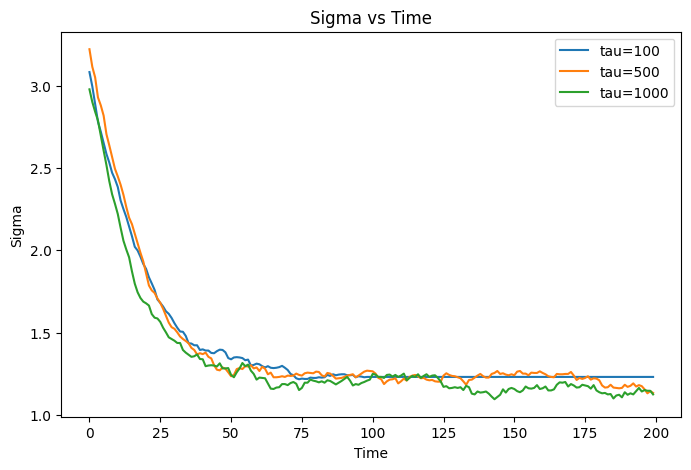

In [59]:
plt.figure(figsize=(8, 5))

for tau in taus:
    plt.plot(results[tau], label=f"tau={tau}")

plt.xlabel("Time")
plt.ylabel("Sigma")
plt.title("Sigma vs Time")
plt.legend()

plt.savefig("avg_sigma_plot.png", dpi=150)
plt.show()